We will add some new properties to the `entity` object to allow it to move about a plane to find food. With this addition, we can simulate a population growth contrained by limited available food resources. 

In [1]:
# Import modules
import matplotlib.pyplot as plt
from vector import Vector
from simpop import *

In [2]:
# Set rendering
plt.rcParams["animation.html"] = "jshtml"

Collision detection:

2 objects
https://www.youtube.com/watch?v=XYzA_kPWyJ8
multiple objects
https://www.youtube.com/watch?v=789weryntzM


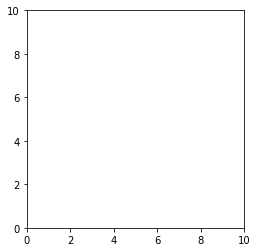

In [3]:
try:
    del env
except Exception:
    pass
env = Environment(.1, .1, 10, 20, 20, (10, 10))

In [4]:
env.run(100)

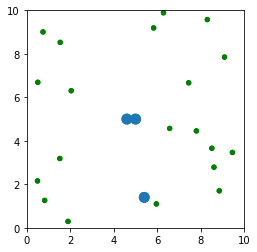

In [5]:
# Import modules
import matplotlib.pyplot as plt
from vector import Vector
from simpop import *
# Set rendering
plt.rcParams["animation.html"] = "jshtml"

try:
    del env ## delete env if already exists (start fresh)
except Exception:
    pass
env = Environment(.1, .1, 0, 20, 20, (10, 10))

e1 = Organism(5, 9, motion=Vector(0, -.2))
e2 = Organism(1, 5, motion=Vector(.2, 0))
e3 = Organism(9, 5, motion=Vector(-.2, 0))
es = [e1, e2, e3]
for e in es:
    env.ents.population.append(e)

env.run(50)

In [138]:
a = Organism(2.5, 3, 1)
print(a)
print(a.radius)

Organism <age: 0, location(2.5, 3)>
1


In [139]:
b = Organism(2, 2.5, .5)
print(b)
print(b.radius)

Organism <age: 0, location(2, 2.5)>
0.5


In [142]:
def resolve_overlap(source, target):
    """ Resolve the overlap between two entities such that the target entity
        and the source entity positions are adjusted to the position along
        their respective vectors at which the entities make first contact.
    """
    print(distance(source, target))
    v_st = Vector(source.x - target.x, source.y - target.y)
    enforce_distance = source.radius + target.radius
    overlap_distance = enforce_distance - v_st.mag

    print(enforce_distance)
    print(overlap_distance)
    # Adjust source
    print(source.radius / overlap_distance)
    print(target.radius / overlap_distance)
    source += v_st.unit * ((source.radius / enforce_distance) * overlap_distance + 5*10**-15)
    target += -v_st.unit * ((target.radius / enforce_distance) * overlap_distance + 5*10**-15)
    print(distance(source, target))



In [143]:
resolve_overlap(a, b)

1.4999999999999996
1.5
4.440892098500626e-16
2251799813685248.0
1125899906842624.0
1.5000000000000095


In [102]:
b.radius / 1.5

0.3333333333333333

In [52]:
collision(a, b)

True

In [53]:
m = distance(a, b)
m

0.7071067811865476

In [54]:
ab = Vector(a.x - b.x, a.y - b.y)
ab

Vector(0.5, 0.5)

In [55]:
r = a.radius + b.radius
r

1.5

In [56]:
d = r - ab.mag
d

0.7928932188134524

In [58]:
s = ab.unit * (d + .01)
s

Vector(0.5677312395916867, 0.5677312395916867)

In [59]:
a += s
print(a)

Organism <age: 0, location(3.0677312395916867, 3.5677312395916867)>


In [60]:
distance(a, b) 

1.5099999999999998

In [61]:
collision(a, b)

False

In [16]:

plt.rcParams["animation.html"] = "jshtml"
try:
    del env ## delete env if already exists (start fresh)
except Exception:
    pass
env = Environment(.1, .1, 0, 1, 20, (10, 10))
env.ents.population.append(a)
env.ents.population.append(b)
env.run(1)

RuntimeError: Can not put single artist in more than one figure